# Fairness Evaluation

# 1 Overview

## 2 Importing Libraries

In [1]:
from pathlib import Path
import gc
import unicodedata

import pandas as pd
import matplotlib.pyplot as plt
import torch

from jiwer import cer, wer
from sacrebleu.metrics import BLEU, CHRF
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    pipeline
)

BASE_DIR = Path("../..").resolve()

OUTPUT_DIR = (
    BASE_DIR
    / "data"
    / "processed"
    / "fairness_evaluation"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DEVICE = (
    0
    if torch.cuda.is_available()
    else -1
)

TORCH_DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

bleu_metric = BLEU()

chrf_metric = CHRF(
    word_order=2
)

print("Device:", TORCH_DEVICE)
print("Output folder:", OUTPUT_DIR)

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Output folder: C:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\data\processed\fairness_evaluation


## 3 Text Normalisation

In [2]:
def normalise_text(text):
    text = unicodedata.normalize(
        "NFKC",
        str(text)
    ).lower()

    text = "".join(
        character
        if character.isalnum()
        or character.isspace()
        else " "
        for character in text
    )

    return " ".join(
        text.split()
    ).strip()

## 4 Whisper Language Fairness

In [3]:
WHISPER_MODEL = "openai/whisper-small"

WHISPER_LANGUAGES = {
    "English": "en",
    "Malay": "ms",
    "Chinese": "zh",
    "Tamil": "ta"
}

FLEURS_TEST = (
    BASE_DIR
    / "data"
    / "processed"
    / "fleurs_whisper"
    / "metadata"
    / "testing.csv"
)

fleurs_test = pd.read_csv(
    FLEURS_TEST
)

print(fleurs_test.shape)

fleurs_test.groupby(
    "language"
).size()

(800, 5)


language
Chinese    200
English    200
Malay      200
Tamil      200
dtype: int64

In [4]:
whisper = pipeline(
    "automatic-speech-recognition",
    model=WHISPER_MODEL,
    device=DEVICE,
    chunk_length_s=30
)

Device set to use cuda:0
Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


In [5]:
whisper_rows = []

for index, row in fleurs_test.iterrows():

    language = row["language"]

    audio_path = Path(
        row["audio_path"]
    )

    if not audio_path.is_absolute():
        audio_path = (
            BASE_DIR
            / Path(
                *[
                    part
                    for part in audio_path.parts
                    if part != ".."
                ]
            )
        )

    result = whisper(
        str(audio_path),
        generate_kwargs={
            "language":
                WHISPER_LANGUAGES[
                    language
                ],
            "task": "transcribe"
        }
    )

    reference = normalise_text(
        row["reference"]
    )

    prediction = normalise_text(
        result["text"]
    )

    whisper_rows.append({
        "language": language,
        "reference": reference,
        "prediction": prediction,
        "cer": cer(
            reference,
            prediction
        ),
        "wer": wer(
            reference,
            prediction
        )
    })

    if (index + 1) % 50 == 0:
        print(
            f"Completed "
            f"{index + 1}/"
            f"{len(fleurs_test)}"
        )

whisper_predictions = pd.DataFrame(
    whisper_rows
)

whisper_predictions.head()

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Completed 50/800
Completed 100/800
Completed 150/800
Completed 200/800
Completed 250/800
Completed 300/800
Completed 350/800
Completed 400/800
Completed 450/800
Completed 500/800
Completed 550/800
Completed 600/800
Completed 650/800
Completed 700/800
Completed 750/800
Completed 800/800


,language,reference,prediction,cer,wer
0,English,its renown for being an epicenter of luxury be...,this renown for being at the center of luxury ...,0.099010,0.363636
1,English,in fact it is not easy to find at all even if ...,in fact it is not easy to find at all even if ...,0.000000,0.000000
2,English,the smaller the rossby number the less active ...,the smaller the raspy number the less active t...,0.033708,0.066667
3,English,there is no universal definition for which man...,there is no universal definition for which man...,0.000000,0.000000
4,English,built by the egyptians in the third century bc...,built by the egyptians in the 3rd century bce ...,0.052632,0.083333


In [6]:
whisper_fairness = (
    whisper_predictions
    .groupby(
        "language"
    )
    .agg(
        Samples=("cer", "size"),
        CER=("cer", "mean"),
        WER=("wer", "mean")
    )
    .reset_index()
)

whisper_fairness[
    ["CER", "WER"]
] = whisper_fairness[
    ["CER", "WER"]
].round(4)

whisper_fairness

,language,Samples,CER,WER
0,Chinese,200,0.5828,0.9999
1,English,200,0.0222,0.0583
2,Malay,200,0.0502,0.1777
3,Tamil,200,0.3058,0.4530


In [7]:
whisper_cer_gap = (
    whisper_fairness["CER"].max()
    - whisper_fairness["CER"].min()
)

whisper_wer_gap = (
    whisper_fairness["WER"].max()
    - whisper_fairness["WER"].min()
)

whisper_best = whisper_fairness.loc[
    whisper_fairness["CER"].idxmin(),
    "language"
]

whisper_weakest = whisper_fairness.loc[
    whisper_fairness["CER"].idxmax(),
    "language"
]

print(
    "Lowest CER:",
    whisper_best
)

print(
    "Highest CER:",
    whisper_weakest
)

print(
    "CER gap:",
    round(
        whisper_cer_gap,
        4
    )
)

print(
    "WER gap:",
    round(
        whisper_wer_gap,
        4
    )
)

Lowest CER: English
Highest CER: Chinese
CER gap: 0.5606
WER gap: 0.9416


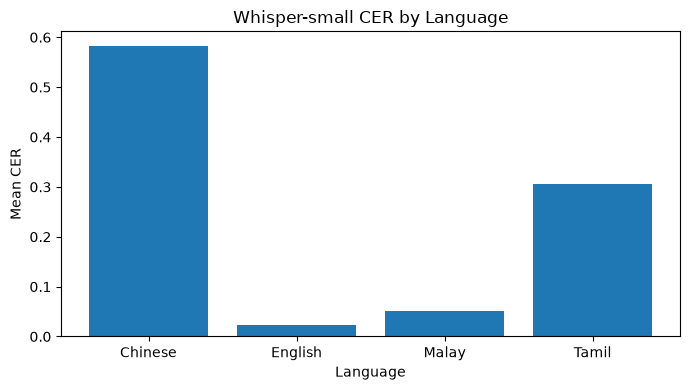

In [8]:
plt.figure(
    figsize=(7, 4)
)

plt.bar(
    whisper_fairness["language"],
    whisper_fairness["CER"]
)

plt.xlabel("Language")
plt.ylabel("Mean CER")
plt.title(
    "Whisper-small CER by Language"
)

plt.tight_layout()
plt.show()

In [9]:
del whisper

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 5 NLLB Translation Language Fairness

In [10]:
NLLB_MODEL = (
    "facebook/"
    "nllb-200-distilled-600M"
)

TARGET_CODES = {
    "Malay": "zsm_Latn",
    "Chinese": "zho_Hans",
    "Tamil": "tam_Taml"
}

OPUS_TEST = (
    BASE_DIR
    / "data"
    / "processed"
    / "opus100_translation"
    / "testing"
)

translation_data = {}

for language in TARGET_CODES:

    translation_data[
        language
    ] = pd.read_csv(
        OPUS_TEST
        / f"{language.lower()}.csv"
    )

    print(
        language,
        len(
            translation_data[
                language
            ]
        )
    )

Malay 100
Chinese 100
Tamil 100


In [11]:
tokenizer = (
    AutoTokenizer
    .from_pretrained(
        NLLB_MODEL
    )
)

translation_model = (
    AutoModelForSeq2SeqLM
    .from_pretrained(
        NLLB_MODEL
    )
    .to(
        TORCH_DEVICE
    )
)

translation_model.eval()

M2M100ForConditionalGeneration(
  (model): M2M100Model(
    (shared): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
    (encoder): M2M100Encoder(
      (embed_tokens): M2M100ScaledWordEmbedding(256206, 1024, padding_idx=1)
      (embed_positions): M2M100SinusoidalPositionalEmbedding()
      (layers): ModuleList(
        (0-11): 12 x M2M100EncoderLayer(
          (self_attn): M2M100Attention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
       

In [12]:
def translate_text(
    text,
    target_code
):
    tokenizer.src_lang = (
        "eng_Latn"
    )

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    inputs = {
        key: value.to(
            TORCH_DEVICE
        )
        for key, value
        in inputs.items()
    }

    with torch.inference_mode():

        generated = (
            translation_model
            .generate(
                **inputs,
                forced_bos_token_id=
                    tokenizer
                    .convert_tokens_to_ids(
                        target_code
                    ),
                max_new_tokens=128
            )
        )

    return (
        tokenizer
        .batch_decode(
            generated,
            skip_special_tokens=True
        )[0]
    )

In [13]:
translation_rows = []

for language, data in (
    translation_data.items()
):

    print(
        f"Evaluating {language}..."
    )

    for index, row in (
        data.iterrows()
    ):

        prediction = translate_text(
            row["source"],
            TARGET_CODES[
                language
            ]
        )

        reference = normalise_text(
            row["reference"]
        )

        prediction = normalise_text(
            prediction
        )

        translation_rows.append({
            "language": language,
            "source": row["source"],
            "reference": reference,
            "prediction": prediction
        })

        if (index + 1) % 25 == 0:
            print(
                language,
                index + 1,
                "/",
                len(data)
            )

translation_predictions = (
    pd.DataFrame(
        translation_rows
    )
)

translation_predictions.head()

Evaluating Malay...
Malay 25 / 100
Malay 50 / 100
Malay 75 / 100
Malay 100 / 100
Evaluating Chinese...
Chinese 25 / 100
Chinese 50 / 100
Chinese 75 / 100
Chinese 100 / 100
Evaluating Tamil...
Tamil 25 / 100
Tamil 50 / 100
Tamil 75 / 100
Tamil 100 / 100


,language,source,reference,prediction
0,Malay,"We appreciate the effort, but the point was no...",kami menghargai usaha tetapi titik itu bukan u...,kami menghargai usaha itu tetapi intinya bukan...
1,Malay,So he let us go,jadi dia biarkan kita pergi,jadi dia membiarkan kita pergi
2,Malay,And they persisted in rejecting them wrongfull...,dan mereka mengingkarinya secara zalim dan som...,dan mereka tetap mendustakannya dengan tidak b...
3,Malay,Drive home from Trenton.,pulang dari trenton,memandu pulang dari trenton
4,Malay,"Now, SpongeBob loved his job as a fry cook mor...",spongebob amat menyayangi pekerjaannya sebagai...,sekarang spongebob suka pekerjaannya sebagai s...


In [14]:
translation_rows_summary = []

for language, group in (
    translation_predictions.groupby(
        "language"
    )
):

    predictions = (
        group["prediction"]
        .tolist()
    )

    references = (
        group["reference"]
        .tolist()
    )

    chrf_score = (
        chrf_metric.corpus_score(
            predictions,
            [references]
        ).score
    )

    bleu_score = (
        bleu_metric.corpus_score(
            predictions,
            [references]
        ).score
    )

    translation_rows_summary.append({
        "language": language,
        "Samples": len(group),
        "chrF++": chrf_score,
        "BLEU": bleu_score
    })

translation_fairness = pd.DataFrame(
    translation_rows_summary
)

translation_fairness[
    ["chrF++", "BLEU"]
] = translation_fairness[
    ["chrF++", "BLEU"]
].round(4)

translation_fairness

,language,Samples,chrF++,BLEU
0,Chinese,100,28.6489,15.5629
1,Malay,100,43.2315,15.8900
2,Tamil,100,38.1402,28.9384


In [15]:
translation_chrf_gap = (
    translation_fairness[
        "chrF++"
    ].max()
    - translation_fairness[
        "chrF++"
    ].min()
)

translation_bleu_gap = (
    translation_fairness[
        "BLEU"
    ].max()
    - translation_fairness[
        "BLEU"
    ].min()
)

translation_best = (
    translation_fairness.loc[
        translation_fairness[
            "chrF++"
        ].idxmax(),
        "language"
    ]
)

translation_weakest = (
    translation_fairness.loc[
        translation_fairness[
            "chrF++"
        ].idxmin(),
        "language"
    ]
)

print(
    "Highest chrF++:",
    translation_best
)

print(
    "Lowest chrF++:",
    translation_weakest
)

print(
    "chrF++ gap:",
    round(
        translation_chrf_gap,
        4
    )
)

print(
    "BLEU gap:",
    round(
        translation_bleu_gap,
        4
    )
)

Highest chrF++: Malay
Lowest chrF++: Chinese
chrF++ gap: 14.5826
BLEU gap: 13.3755


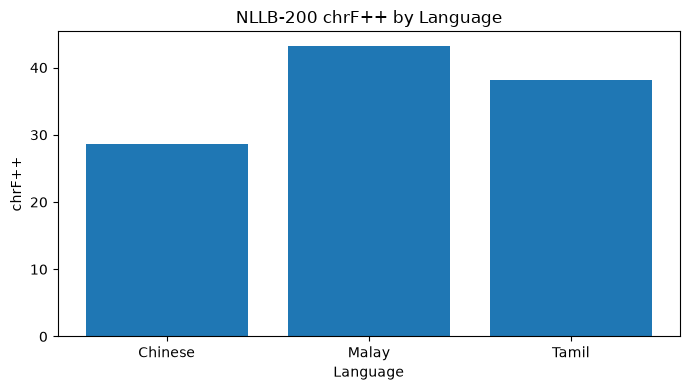

In [16]:
plt.figure(
    figsize=(7, 4)
)

plt.bar(
    translation_fairness[
        "language"
    ],
    translation_fairness[
        "chrF++"
    ]
)

plt.xlabel("Language")
plt.ylabel("chrF++")
plt.title(
    "NLLB-200 chrF++ by Language"
)

plt.tight_layout()
plt.show()

In [17]:
del translation_model
del tokenizer

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 6 MERaLiON Gender Fairness

In [18]:
prediction_files = list(
    BASE_DIR.rglob(
        "selected_audio_model_test_predictions.csv"
    )
)

if not prediction_files:
    raise FileNotFoundError(
        "selected_audio_model_test_predictions.csv "
        "was not found."
    )

AUDIO_PREDICTIONS = max(
    prediction_files,
    key=lambda path:
        path.stat().st_mtime
)

print(
    "Using:",
    AUDIO_PREDICTIONS
)

audio_predictions = pd.read_csv(
    AUDIO_PREDICTIONS
).copy()

audio_predictions["actor"] = (
    audio_predictions["actor"]
    .astype(int)
)

audio_predictions["Actual Emotion"] = (
    audio_predictions["Actual Emotion"]
    .astype(str)
    .str.strip()
    .str.lower()
)

audio_predictions["Predicted Emotion"] = (
    audio_predictions["Predicted Emotion"]
    .astype(str)
    .str.strip()
    .str.lower()
)

audio_predictions["speaker_sex"] = (
    audio_predictions["actor"]
    .apply(
        lambda actor:
            "male"
            if actor % 2 == 1
            else "female"
    )
)

audio_predictions.head()

Using: C:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\notebooks\model_experiments\outputs\audio\selected_audio_model_test_predictions.csv


,actor,Actual Emotion,Predicted Emotion,speaker_sex
0,17,neutral,sadness,male
1,17,neutral,neutral,male
2,17,neutral,neutral,male
3,17,neutral,neutral,male
4,17,happiness,happiness,male


In [19]:
audio_rows = []

for speaker_sex, group in (
    audio_predictions.groupby(
        "speaker_sex"
    )
):

    y_true = group[
        "Actual Emotion"
    ]

    y_pred = group[
        "Predicted Emotion"
    ]

    audio_rows.append({
        "speaker_sex":
            speaker_sex,

        "Speakers":
            group[
                "actor"
            ].nunique(),

        "Samples":
            len(group),

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Macro Precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro Recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "Macro-F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
    })

audio_fairness_df = pd.DataFrame(
    audio_rows
)

audio_fairness_df

,speaker_sex,Speakers,Samples,Accuracy,Macro Precision,Macro Recall,Macro-F1
0,female,4,176,0.721591,0.787703,0.718750,0.700709
1,male,4,176,0.625000,0.670947,0.630208,0.616257


In [20]:
if len(audio_fairness_df) == 2:

    audio_accuracy_gap = (
        audio_fairness_df["Accuracy"].max()
        - audio_fairness_df["Accuracy"].min()
    )

    audio_f1_gap = (
        audio_fairness_df["Macro-F1"].max()
        - audio_fairness_df["Macro-F1"].min()
    )
    gap_summary_df = pd.DataFrame([{
        "Metric": "Audio fairness gap",
        "Accuracy Gap": audio_accuracy_gap,
        "Macro-F1 Gap": audio_f1_gap
    }])

    gap_summary_df

## 7 Fairness Evaluation Coverage

In [21]:
fairness_coverage = pd.DataFrame([
    {
        "Component": "Whisper",
        "Fairness dimension":
            "Language",
        "Status": "Evaluated"
    },
    {
        "Component": "NLLB-200",
        "Fairness dimension":
            "Language",
        "Status": "Evaluated"
    },
    {
        "Component": "MERaLiON",
        "Fairness dimension":
            "Speaker sex",
        "Status": "Evaluated"
    },
    {
        "Component": "RoBERTa",
        "Fairness dimension":
            "Demographic groups",
        "Status":
            "Not evaluated - "
            "no demographic labels "
            "in CancerEmo"
    },
    {
        "Component": "ViT",
        "Fairness dimension":
            "Demographic groups",
        "Status":
            "Not evaluated - "
            "no demographic labels "
            "in RAF-DB evaluation files"
    }
])

fairness_coverage

,Component,Fairness dimension,Status
0,Whisper,Language,Evaluated
1,NLLB-200,Language,Evaluated
2,MERaLiON,Speaker sex,Evaluated
3,RoBERTa,Demographic groups,Not evaluated - no demographic labels in Cance...
4,ViT,Demographic groups,Not evaluated - no demographic labels in RAF-D...


## 8 Fairness Gap Summary

In [22]:
fairness_summary = pd.DataFrame([
    {
        "Evaluation":
            "Whisper language",
        "Metric":
            "CER",
        "Gap":
            whisper_cer_gap
    },
    {
        "Evaluation":
            "Whisper language",
        "Metric":
            "WER",
        "Gap":
            whisper_wer_gap
    },
    {
        "Evaluation":
            "NLLB language",
        "Metric":
            "chrF++",
        "Gap":
            translation_chrf_gap
    },
    {
        "Evaluation":
            "NLLB language",
        "Metric":
            "BLEU",
        "Gap":
            translation_bleu_gap
    },
    {
        "Evaluation":
            "MERaLiON speaker sex",
        "Metric":
            "Accuracy",
        "Gap":
            audio_accuracy_gap
    },
    {
        "Evaluation":
            "MERaLiON speaker sex",
        "Metric":
            "Macro-F1",
        "Gap":
            audio_f1_gap
    }
])

fairness_summary[
    "Gap"
] = fairness_summary[
    "Gap"
].round(4)

fairness_summary

,Evaluation,Metric,Gap
0,Whisper language,CER,0.5606
1,Whisper language,WER,0.9416
2,NLLB language,chrF++,14.5826
3,NLLB language,BLEU,13.3755
4,MERaLiON speaker sex,Accuracy,0.0966
5,MERaLiON speaker sex,Macro-F1,0.0845
